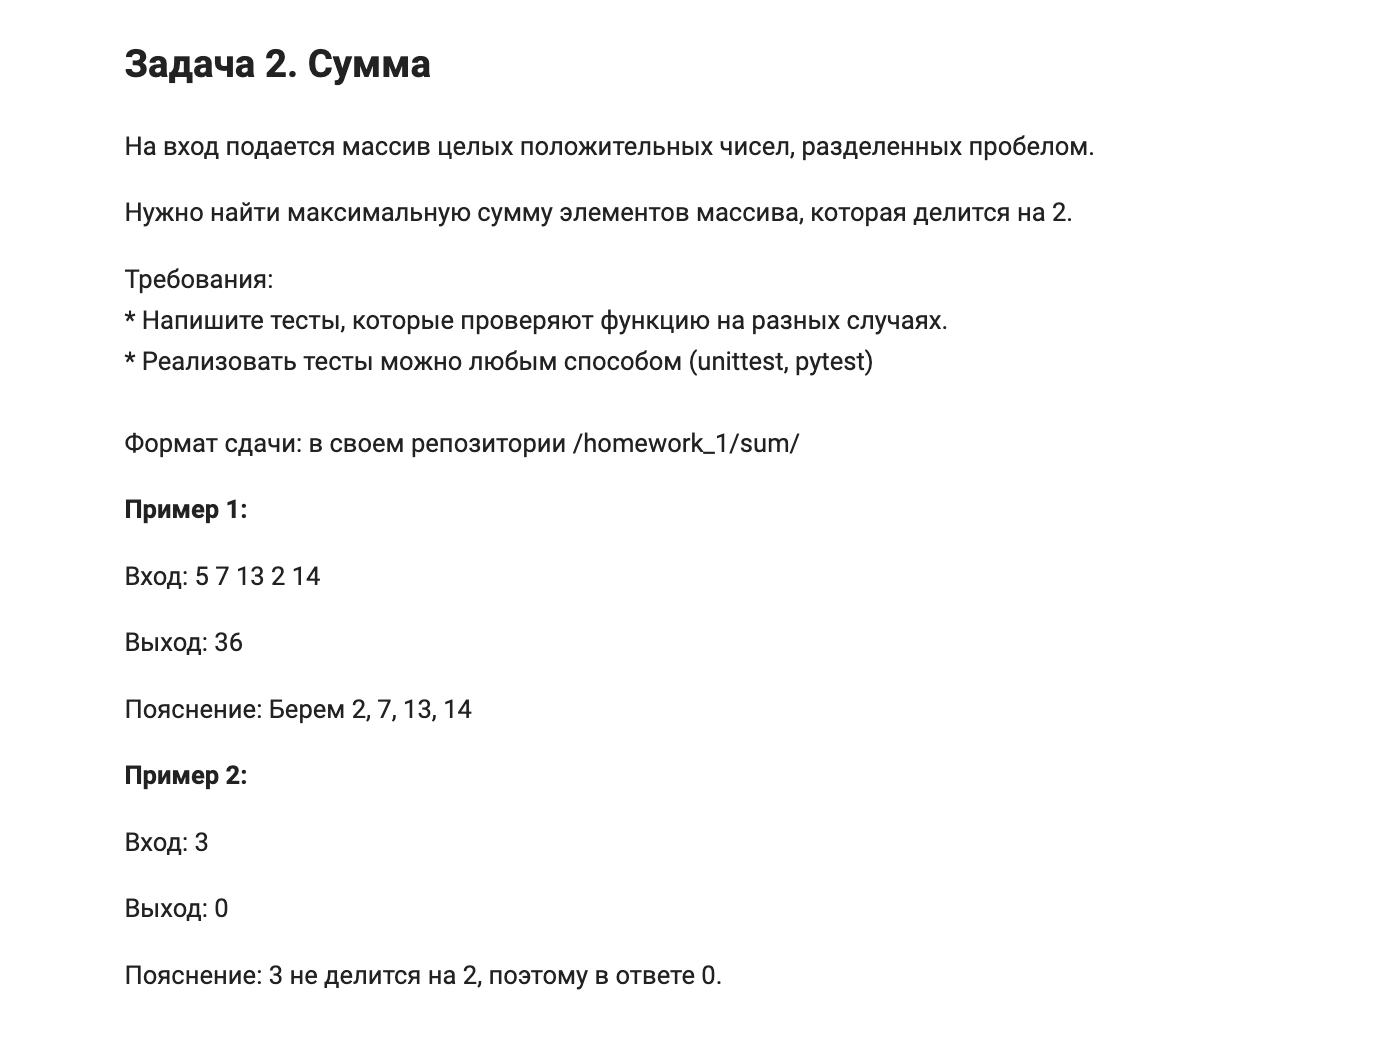

# Ход решения

Так как все числа положительные, для максимальной суммы выгодно взять как можно больше элементов.

По сути в задаче есть два случая:
* если сумма всех элементов четная, то это и есть максимальная подходящая сумма;
* если сумма нечетная, нужно изменить ее четность. Для этого достаточно убрать одно нечетное число. Чтобы потерять как можно меньше, убираем **минимальное нечетное число**.

Удалять четное число бессмысленно: четность суммы не изменится. Удалять несколько положительных чисел тоже невыгодно, если нужную четность можно получить удалением одного минимального нечетного.

# Граничные случаи

- Один четный элемент, тогда ответ равен этому элементу.
- Один нечетный элемент, тогда ответ `0`, как во втором примере из условия.
- Все элементы четные, тогда берем весь массив.
- Если сумма нечетная, в массиве обязательно есть хотя бы одно нечетное число, поэтому минимум среди нечетных всегда существует.

# Сложность алгоритма

Пусть `n` — количество элементов массива.

- `sum(nums)` проходит по всем `n` элементам.
- Если сумма нечетная, поиск минимального нечетного делает еще один проход по массиву.
- Поэтому алгоритм выполняет не более `2n` операций прохода по элементам: временная сложность — **`O(n)`**. При этом хотя бы один полный проход нужен всегда, то есть также **`Ω(n)`**, а значит итогово **`Θ(n)`**.
- На входной массив тратим **`O(n)`** памяти. Дополнительная память функции =  **`O(1)`**, так как генератор в `min` не создает отдельный список.

# Реализация алгоритма

In [1]:
def max_even_sum_in_list(nums):
    total = sum(nums)

    if total % 2 == 0:
        return total

    return total - min(x for x in nums if x % 2 == 1)

# Проверка на нетривиальном примере

In [9]:
a = list(map(int, input().split()))
print(max_even_sum_in_list(a))

5 7 13 2 14 15 17 20
88


# Визуализация работы алгоритма

Рассмотрим нетривиальный пример: `[5, 7, 13, 2, 14, 15, 17, 20]`.

| Шаг | Действие | Результат |
| --- | --- | --- |
| 1 | Считаем сумму всех элементов | `5 + 7 + 13 + 2 + 14 + 15 + 17 + 20 = 93` |
| 2 | Сумма нечетная, ищем нечетные элементы | `5, 7, 13, '15', '17'` |
| 3 | Берем минимальный нечетный элемент | `5` |
| 4 | Убираем его из суммы | `93 - 5 = 88` |

Получили `88` — четную сумму. Она максимальна, потому что для изменения четности мы убрали минимально возможный положительный элемент.

# Тесты

По условию на вход подается массив положительных целых чисел, поэтому пустой массив, отрицательные числа и нецелые значения отдельно не проверяем.

Проверим:
* оба примера из условия
* массив только из четных чисел
* четную сумму с нечетными элементами
* нечетную сумму
* массив только из нечетных чисел
* случаи с одним элементом.

In [10]:
import unittest


class TestMaxEvenSum(unittest.TestCase):
    def test_examples(self):
        self.assertEqual(max_even_sum_in_list([5, 7, 13, 2, 14]), 36)
        self.assertEqual(max_even_sum_in_list([3]), 0)

    def test_all_even(self):
        self.assertEqual(max_even_sum_in_list([2, 4, 6, 8]), 20)

    def test_even_total_with_odd_numbers(self):
        self.assertEqual(max_even_sum_in_list([1, 3, 2, 4]), 10)

    def test_odd_total(self):
        self.assertEqual(max_even_sum_in_list([1, 2, 4]), 6)
        self.assertEqual(max_even_sum_in_list([9, 2, 3, 8, 5]), 24)

    def test_all_odd(self):
        self.assertEqual(max_even_sum_in_list([1, 3, 5]), 8)

    def test_single_element(self):
        self.assertEqual(max_even_sum_in_list([8]), 8)
        self.assertEqual(max_even_sum_in_list([7]), 0)


_ = unittest.main(argv=[''], exit=False)

......
----------------------------------------------------------------------
Ran 6 tests in 0.008s

OK
